In [4]:
# import packages
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

In [6]:
pip install openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.1/242.1 kB 172.9 kB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


# Data Preparation

In [9]:
df = pd.read_excel('Economist Intelligence Case Study_Data.xlsx', 'crop_production')


In [7]:
rainfall = pd.read_excel('Economist Intelligence Case Study_Data.xlsx', 'rainfall')

In [131]:
df.head()

,State_Name,Sub_Division,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,ANDAMAN & NICOBAR ISLANDS,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,ANDAMAN & NICOBAR ISLANDS,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,ANDAMAN & NICOBAR ISLANDS,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,ANDAMAN & NICOBAR ISLANDS,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,ANDAMAN & NICOBAR ISLANDS,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


In [10]:
crop = df.groupby(['Sub_Division','Crop_Year']).sum().reset_index()

In [288]:
crop.head()

,Sub_Division,Crop_Year,Area,Production
0,ANDAMAN & NICOBAR ISLANDS,2000,44518.00,89060914.00
1,ANDAMAN & NICOBAR ISLANDS,2001,41163.00,89718700.00
2,ANDAMAN & NICOBAR ISLANDS,2002,45231.40,94387137.67
3,ANDAMAN & NICOBAR ISLANDS,2003,44799.40,95296454.67
4,ANDAMAN & NICOBAR ISLANDS,2004,45308.77,87186497.63


In [11]:
crop.shape

(397, 4)

In [8]:
# Missing values in rainfall data
rainfall.isnull().sum()

STATE_UT_NAME     0
YEAR              0
JAN               4
FEB               3
MAR               6
APR               4
MAY               3
JUN               5
JUL               7
AUG               4
SEP               6
OCT               7
NOV              11
DEC              10
ANNUAL           26
Jan-Feb           6
Mar-May           9
Jun-Sep          10
Oct-Dec          13
dtype: int64

In [12]:
rain = rainfall.loc[rainfall['YEAR']>=1997].groupby(['STATE_UT_NAME','YEAR']).sum().reset_index()

In [13]:
rain.head()

,STATE_UT_NAME,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec
0,ANDAMAN & NICOBAR ISLANDS,1997,9.5,0.0,0.2,15.6,281.1,199.5,918.5,430.6,440.2,128.7,292.8,38.4,2755.1,9.5,296.9,1988.8,459.9
1,ANDAMAN & NICOBAR ISLANDS,1998,0.9,0.0,0.0,0.0,348.9,600.0,364.5,258.9,337.8,618.6,227.8,89.0,2846.4,0.9,348.9,1561.2,935.4
2,ANDAMAN & NICOBAR ISLANDS,1999,46.8,44.6,14.2,270.6,257.4,295.0,408.5,329.2,325.3,437.5,124.9,145.7,2699.7,91.4,542.2,1358.0,708.1
3,ANDAMAN & NICOBAR ISLANDS,2000,53.0,59.0,171.3,218.1,422.8,357.0,176.3,460.8,250.1,321.2,158.3,115.2,2763.2,112.0,812.2,1244.2,594.7
4,ANDAMAN & NICOBAR ISLANDS,2001,89.0,15.7,143.3,30.1,705.3,370.7,341.3,469.0,334.4,267.6,222.6,91.8,3080.9,104.7,878.7,1515.4,582.0


In [14]:
rain_crop = pd.merge(crop, rain, left_on=['Sub_Division','Crop_Year'], right_on=['STATE_UT_NAME','YEAR'], how='inner')


In [15]:
rain_crop.shape

(397, 23)

# Analysis

# Crop Analysis

In [16]:
df1 = df.groupby(['State_Name','Crop_Year']).sum().reset_index()

In [17]:
df1.sort_values(['State_Name','Crop_Year'], ascending = True)

,State_Name,Crop_Year,Area,Production
0,Andaman and Nicobar Islands,2000,44518.00,89060914.00
1,Andaman and Nicobar Islands,2001,41163.00,89718700.00
2,Andaman and Nicobar Islands,2002,45231.40,94387137.67
3,Andaman and Nicobar Islands,2003,44799.40,95296454.67
4,Andaman and Nicobar Islands,2004,45308.77,87186497.63
...,...,...,...,...
514,West Bengal,2010,7246877.00,38308645.00
515,West Bengal,2011,7755360.00,36777774.00
516,West Bengal,2012,7850937.00,38918275.00
517,West Bengal,2013,7999815.00,37901281.00


In [18]:
df.head()

,State_Name,Sub_Division,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,ANDAMAN & NICOBAR ISLANDS,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,ANDAMAN & NICOBAR ISLANDS,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,ANDAMAN & NICOBAR ISLANDS,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,ANDAMAN & NICOBAR ISLANDS,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,ANDAMAN & NICOBAR ISLANDS,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


In [19]:
len(df.State_Name.unique())

33

In [20]:
df1 = df.loc[df['Crop_Year'] == 2010].groupby(['Sub_Division','Crop_Year']).sum().reset_index()

In [21]:
df1

,Sub_Division,Crop_Year,Area,Production
0,ANDAMAN & NICOBAR ISLANDS,2010,41697.92,9.505591e+07
1,ARUNACHAL PRADESH,2010,239120.00,3.993450e+05
2,ASSAM & MEGHALAYA,2010,3658140.00,1.959354e+08
3,Andhra Pradesh,2010,7505666.00,2.873887e+07
4,BIHAR,2010,6706495.00,2.411544e+07
5,CHHATTISGARH,2010,5552213.00,7.887949e+06
6,Gujarat,2010,11282500.00,4.411530e+07
7,HARYANA DELHI & CHANDIGARH,2010,5816638.00,2.022181e+07
8,HIMACHAL PRADESH,2010,827874.00,1.656895e+06
9,JHARKHAND,2010,116429.00,2.182251e+05


In [22]:
Yearly_crop_prod = df.loc[df['Crop_Year'] <= 2014].groupby(['Crop_Year']).sum().reset_index()


In [328]:
#Yearly_crop_prod.to_excel('Yearly_crop_prod.xlsx')
print('DataFrame is written to Excel File successfully.')

DataFrame is written to Excel File successfully.


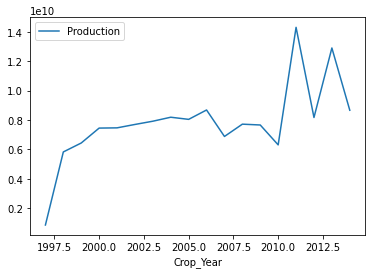

In [239]:
Yearly_crop_prod.plot(x="Crop_Year", y="Production", kind="line")
plt.show()

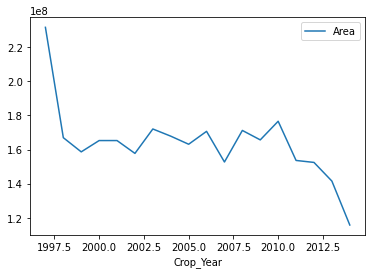

In [240]:
Yearly_crop_prod.plot(x="Crop_Year", y="Area", kind="line")
plt.show()

In [23]:
Season_crop_prod = df.groupby(['Season']).sum().reset_index()
# .iloc[:4,:]
Season_crop_prod.head()

,Season,Crop_Year,Area,Production
0,Autumn,9931847,4.807113e+07,6.441377e+07
1,Kharif,192433963,1.404845e+09,4.029970e+09
2,Rabi,134375352,9.479874e+08,2.051688e+09
3,Summer,29783876,7.598406e+07,1.706579e+08
4,Whole Year,114886975,2.573005e+08,1.344248e+11


In [24]:
#Season_crop_prod.to_excel('Season_crop_prod.xlsx')
print('DataFrame is written to Excel File successfully.')

DataFrame is written to Excel File successfully.


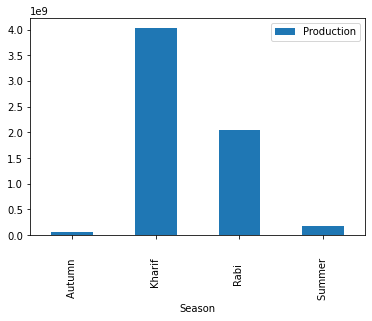

In [249]:
Season_crop_prod.plot(x="Season", y="Production", kind="bar")
plt.show()

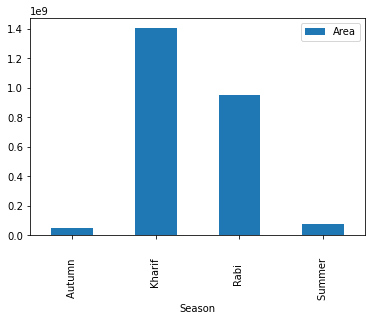

In [250]:
Season_crop_prod.plot(x="Season", y="Area", kind="bar")
plt.show()

In [25]:
top10_high_prod_crop = df.groupby(['Crop']).sum().sort_values(by = ['Production'],ascending = False).reset_index().head(10)
top10_high_prod_crop.head()


,Crop,Crop_Year,Area,Production
0,Coconut,3981344,2.838168e+07,1.299816e+11
1,Sugarcane,15886006,7.667598e+07,5.535682e+09
2,Rice,30294167,7.471253e+08,1.605470e+09
3,Wheat,15841136,4.707136e+08,1.332826e+09
4,Potato,13902444,2.223287e+07,4.248263e+08


In [26]:
Top_Crop_distribution = df.loc[df['Crop']=='Coconut '].groupby(['Crop','Sub_Division','Crop_Year']).sum().sort_values(by = ['Production'],ascending = False).reset_index()
Top_Crop_distribution



,Crop,Sub_Division,Crop_Year,Area,Production
0,Coconut,KERALA,2005,897833.0,6.326000e+09
1,Coconut,TAMIL NADU,2011,421495.0,6.218213e+09
2,Coconut,KERALA,2006,872943.0,6.054000e+09
3,Coconut,KERALA,2004,899267.0,6.001000e+09
4,Coconut,KERALA,2014,793856.0,5.947000e+09
...,...,...,...,...,...
119,Coconut,CHHATTISGARH,2011,73.0,0.000000e+00
120,Coconut,CHHATTISGARH,2008,77.0,0.000000e+00
121,Coconut,CHHATTISGARH,2014,59.0,0.000000e+00
122,Coconut,CHHATTISGARH,2012,100.0,0.000000e+00


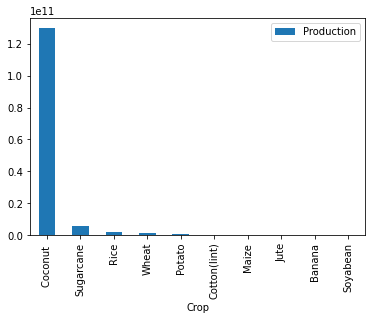

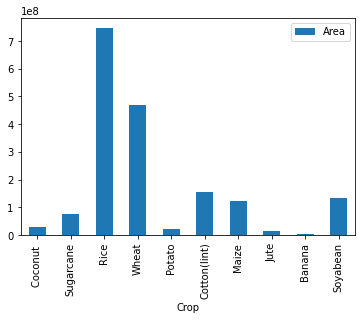

In [27]:
top10_high_prod_crop.plot(x="Crop", y="Production", kind="bar")
plt.show()
top10_high_prod_crop.plot(x="Crop", y="Area", kind="bar")
plt.show()


# RainFall Analysis

In [200]:
rainfall.head()

,STATE_UT_NAME,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec
0,ANDAMAN & NICOBAR ISLANDS,1901,49.2,87.1,29.2,2.3,528.8,517.5,365.1,481.1,332.6,388.5,558.2,33.6,3373.2,136.3,560.3,1696.3,980.3
1,ANDAMAN & NICOBAR ISLANDS,1902,0.0,159.8,12.2,0.0,446.1,537.1,228.9,753.7,666.2,197.2,359.0,160.5,3520.7,159.8,458.3,2185.9,716.7
2,ANDAMAN & NICOBAR ISLANDS,1903,12.7,144.0,0.0,1.0,235.1,479.9,728.4,326.7,339.0,181.2,284.4,225.0,2957.4,156.7,236.1,1874.0,690.6
3,ANDAMAN & NICOBAR ISLANDS,1904,9.4,14.7,0.0,202.4,304.5,495.1,502.0,160.1,820.4,222.2,308.7,40.1,3079.6,24.1,506.9,1977.6,571.0
4,ANDAMAN & NICOBAR ISLANDS,1905,1.3,0.0,3.3,26.9,279.5,628.7,368.7,330.5,297.0,260.7,25.4,344.7,2566.7,1.3,309.7,1624.9,630.8


In [201]:
#selecting data for year 1997 onwards as crop production data is available for that time period

rf1 = rainfall.loc[rainfall['YEAR']>=1997]
rf1.head()

,STATE_UT_NAME,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec
91,ANDAMAN & NICOBAR ISLANDS,1997,9.5,0.0,0.2,15.6,281.1,199.5,918.5,430.6,440.2,128.7,292.8,38.4,2755.1,9.5,296.9,1988.8,459.9
92,ANDAMAN & NICOBAR ISLANDS,1998,0.9,0.0,0.0,0.0,348.9,600.0,364.5,258.9,337.8,618.6,227.8,89.0,2846.4,0.9,348.9,1561.2,935.4
93,ANDAMAN & NICOBAR ISLANDS,1999,46.8,44.6,14.2,270.6,257.4,295.0,408.5,329.2,325.3,437.5,124.9,145.7,2699.7,91.4,542.2,1358.0,708.1
94,ANDAMAN & NICOBAR ISLANDS,2000,53.0,59.0,171.3,218.1,422.8,357.0,176.3,460.8,250.1,321.2,158.3,115.2,2763.2,112.0,812.2,1244.2,594.7
95,ANDAMAN & NICOBAR ISLANDS,2001,89.0,15.7,143.3,30.1,705.3,370.7,341.3,469.0,334.4,267.6,222.6,91.8,3080.9,104.7,878.7,1515.4,582.0


In [351]:
total_rainfall_state_wise = rainfall.groupby(['STATE_UT_NAME'])['ANNUAL'].sum().reset_index().sort_values(by = ['ANNUAL'])



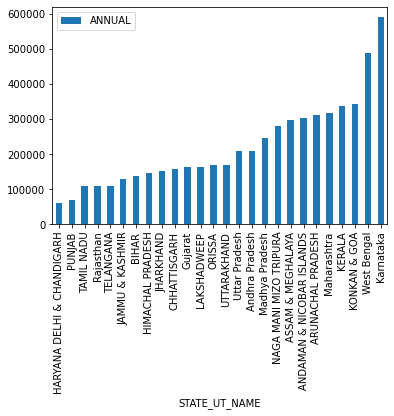

In [352]:
total_rainfall_state_wise.plot(x="STATE_UT_NAME", y="ANNUAL", kind="bar")
plt.show()

In [219]:
month_wise_rainfall = pd.DataFrame(rainfall.sum()).iloc[2:14,:].reset_index()
month_wise_rainfall

,index,0
0,JAN,77952.5
1,FEB,89685.3
2,MAR,112446.3
3,APR,177340.0
4,MAY,352424.1
5,JUN,946493.8
6,JUL,1426703.7
7,AUG,1193563.5
8,SEP,811157.5
9,OCT,392438.3


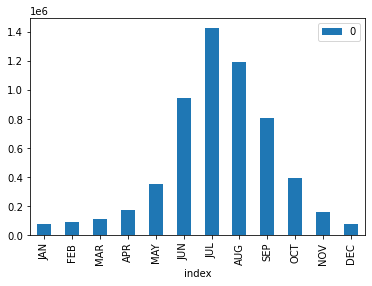

In [221]:
month_wise_rainfall.plot(x="index", y=0, kind="bar")
plt.show()

In [39]:
# import geopandas as gpd

# gdf = gpd.read_file("https://gist.githubusercontent.com/planemad/d347ad7485344fb0ba4b470721825427/raw/4c683c9e1c46bc7373dc3df34202080e1a69c6e3/india-district-imd.geojson")

[['YEAR','ANNUAL']]

In [318]:
Yearly_rainfall_trend = pd.DataFrame(rainfall.groupby(['YEAR']).sum()).reset_index()
Yearly_rainfall_trend.head()

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec
0,1901,1232.7,1417.8,738.4,1623.6,2465.2,6811.3,10192.3,10546.4,4695.4,2579.4,2266.5,378.3,44947.5,2650.3,4827.2,32245.7,5224.2
1,1902,298.2,290.7,733.3,1602.0,2521.4,5908.7,12290.1,8393.0,9051.4,3035.0,1521.0,1160.3,46805.6,588.5,4857.2,35643.5,5716.7
2,1903,589.8,502.0,930.2,594.1,2808.3,6019.6,12673.8,10481.9,7581.7,4387.1,1649.8,758.6,47596.9,1091.9,4331.9,36756.8,6716.2
3,1904,409.4,328.7,1010.8,1449.1,3235.9,8312.0,10919.0,7595.5,5859.1,2959.3,691.5,517.0,43287.0,737.7,5695.7,32685.6,4168.0
4,1905,812.0,716.7,1432.9,1216.4,2675.3,5768.2,10091.0,8637.3,6274.1,2735.9,560.9,595.2,41516.2,1528.6,5324.5,30771.0,3892.2


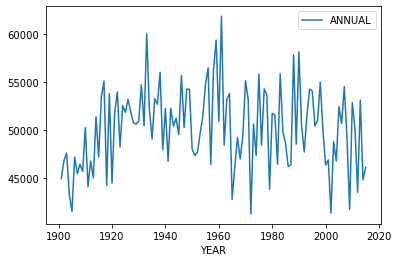

In [316]:
Yearly_rainfall_trend.plot(x="YEAR", y="ANNUAL", kind="line")
plt.show()

# Crop & RainFall

In [36]:
related = rain_crop[['Sub_Division','Crop_Year','Area','Production','ANNUAL']]
related.head()

,Sub_Division,Crop_Year,Area,Production,ANNUAL
0,ANDAMAN & NICOBAR ISLANDS,2000,44518.00,89060914.00,2763.2
1,ANDAMAN & NICOBAR ISLANDS,2001,41163.00,89718700.00,3080.9
2,ANDAMAN & NICOBAR ISLANDS,2002,45231.40,94387137.67,2620.2
3,ANDAMAN & NICOBAR ISLANDS,2003,44799.40,95296454.67,2355.9
4,ANDAMAN & NICOBAR ISLANDS,2004,45308.77,87186497.63,2460.1


In [34]:
related_1 = related.groupby(['Sub_Division']).sum().reset_index()
related_1

,Sub_Division,Crop_Year,Area,Production,ANNUAL
0,ANDAMAN & NICOBAR ISLANDS,16031,3.378961e+05,7.182232e+08,21796.8
1,ARUNACHAL PRADESH,36099,4.364346e+06,6.823913e+06,44773.6
2,ASSAM & MEGHALAYA,36099,7.441379e+07,2.123864e+09,42870.4
3,Andhra Pradesh,36099,1.315458e+08,1.732459e+10,33150.4
4,BIHAR,36099,1.282720e+08,3.664836e+08,20637.8
5,CHHATTISGARH,30105,8.303966e+07,1.009519e+08,18972.0
6,Gujarat,32072,1.549440e+08,5.242913e+08,24565.1
7,HARYANA DELHI & CHANDIGARH,32072,8.960983e+07,3.813378e+08,7957.0
8,HIMACHAL PRADESH,24043,1.000388e+07,1.780517e+07,13365.1
9,JAMMU & KASHMIR,24053,9.264623e+06,1.329102e+07,13176.4


In [79]:
state_highest_crop = related.loc[related['Sub_Division'] == 'KERALA']
state_lowest_crop = related.loc[related['Sub_Division'] == 'ARUNACHAL PRADESH']
Tamilnadu_rainfall_crop = related.loc[related['Sub_Division'] == 'TAMIL NADU']
Chandigarh_rainfall_crop = related.loc[related['Sub_Division'] == 'HARYANA DELHI & CHANDIGARH']
state_highest_crop

,Sub_Division,Crop_Year,Area,Production,ANNUAL
158,KERALA,1997,1499233.00,8.976476e+06,3252.4
159,KERALA,1998,1814763.00,5.136507e+09,3151.5
160,KERALA,1999,1877931.00,5.684573e+09,2914.6
161,KERALA,2000,1888426.00,5.540247e+09,2412.6
162,KERALA,2001,2445363.00,5.483809e+09,2931.1
163,KERALA,2002,2816545.00,5.714479e+09,2507.4
164,KERALA,2003,2106924.00,5.880749e+09,2394.9
165,KERALA,2004,1829339.00,6.005025e+09,2886.1
166,KERALA,2005,1818834.00,6.330149e+09,3031.1
167,KERALA,2006,1738085.00,6.058003e+09,3420.6


In [75]:
Tamilnadu_Crop_types = df.loc[df['State_Name'] == 'Tamil Nadu'].groupby(['Crop']).sum().sort_values(by =['Production'], ascending = False).reset_index()
Chandigarh_Crop_types = df.loc[df['State_Name'] == 'Chandigarh'].groupby(['Crop']).sum().sort_values(by =['Production'], ascending = False).reset_index()

Chandigarh_Crop_types


,Crop,Crop_Year,Area,Production
0,Wheat,26052,8730.0,39465.0
1,Potato,26052,583.0,13795.0
2,Maize,26052,1640.0,4225.0
3,Rice,26052,850.0,3853.0
4,Onion,26052,105.0,1884.0
5,Rapeseed &Mustard,10000,400.0,521.0
6,Arhar/Tur,5997,108.0,88.0
7,Urad,10000,57.0,51.0
8,Masoor,7998,25.0,32.5
9,Sunflower,4003,10.0,28.0


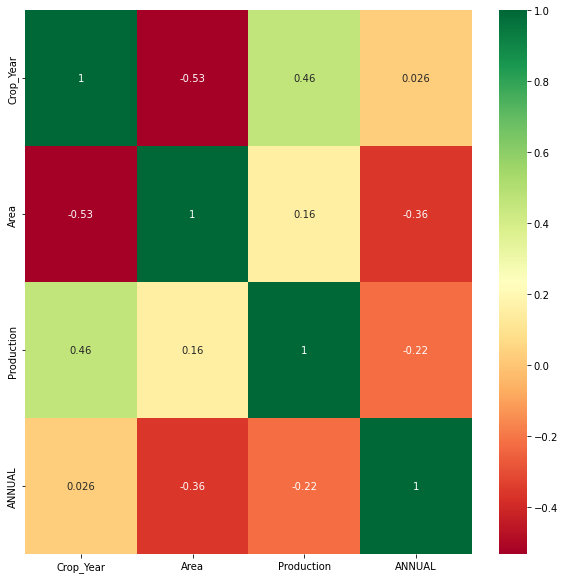

In [78]:
corrmat = state_highest_crop.corr()
corr_features = corrmat.index
plt.figure(figsize = (10,10))
g = sns.heatmap(state_highest_crop[corr_features].corr(),annot= True,cmap = "RdYlGn")

In [77]:
Chandigarh_Crop_types.to_excel('Chandigarh_Crop_types.xlsx')
print('DataFrame is written to Excel File successfully.')

DataFrame is written to Excel File successfully.


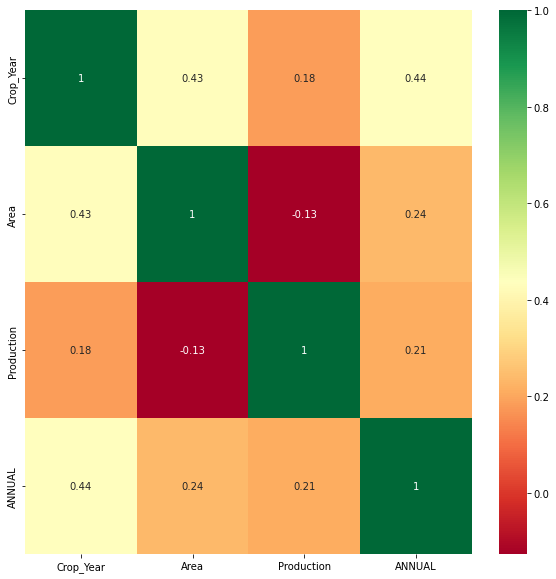

In [35]:
corrmat = related_1.corr()
corr_features = corrmat.index
plt.figure(figsize = (10,10))
g = sns.heatmap(related_1[corr_features].corr(),annot= True,cmap = "RdYlGn")

In [353]:
state_wise = related.groupby(['Sub_Division']).sum().sort_values(by= 'Production', ascending = False).reset_index()
state_wise.head()

,Sub_Division,Crop_Year,Area,Production,ANNUAL
0,KERALA,36099,3.190807e+07,9.788005e+10,52346.8
1,Andhra Pradesh,36099,1.315458e+08,1.732459e+10,33150.4
2,TAMIL NADU,36099,9.644661e+07,1.246117e+10,15917.3
3,Uttar Pradesh,36099,4.336316e+08,3.234493e+09,26516.8
4,ASSAM & MEGHALAYA,36099,7.441379e+07,2.123864e+09,42870.4


In [314]:
year_wise.to_excel('Year_wise_rain_and_crop.xlsx')
print('DataFrame is written to Excel File successfully.')

DataFrame is written to Excel File successfully.


In [313]:
year_wise = related.groupby(['Crop_Year']).sum().sort_values(by= 'Production', ascending = False).reset_index()
year_wise.head()

,Crop_Year,Area,Production,ANNUAL
0,2011,1.536099e+08,1.430882e+10,40193.3
1,2013,1.415094e+08,1.290356e+10,41969.5
2,2006,1.706730e+08,8.681723e+09,47527.8
3,2014,1.157417e+08,8.664513e+09,34442.8
4,2004,1.678522e+08,8.189300e+09,45200.0


# Analysis for different regions and crop type analysis